<a href="https://colab.research.google.com/github/Ajitgupta31/PYTHON-Programming/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression: Pointwise Explanation and Code Implementation

### 1. What is Linear Regression?

-   **Definition**: Linear Regression is a statistical method used to model the relationship between a dependent variable (target) and one or more independent variables (features) by fitting a linear equation to the observed data.
-   **Purpose**: It's primarily used for predictive analysis to forecast future outcomes or understand the strength of the relationship between variables.
-   **Type**: It's a fundamental algorithm in supervised learning for regression tasks.

### 2. Mathematical Foundation

-   **Simple Linear Regression**: Involves one independent variable. The equation is:
    $$y = \beta_0 + \beta_1 x + \epsilon$$
    Where:
    -   `y`: Dependent variable (the value we want to predict)
    -   `x`: Independent variable (the feature used for prediction)
    -   `β₀`: Intercept (the value of y when x is 0)
    -   `β₁`: Slope (the change in y for a one-unit change in x)
    -   `ε`: Error term (the irreducible error)

-   **Multiple Linear Regression**: Involves multiple independent variables. The equation is:
    $$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$$

### 3. Key Concepts

-   **Independent Variable (Feature)**: The input variable(s) used to predict the dependent variable. Also called predictor, explanatory variable.
-   **Dependent Variable (Target)**: The output variable that is being predicted. Also called response variable.
-   **Coefficients (Slope and Intercept)**: These are the parameters (β₀, β₁) that the model learns from the training data. They define the line of best fit.
-   **Residuals (Errors)**: The difference between the actual observed value of the dependent variable and the value predicted by the model ($y - \hat{y}$). Linear Regression aims to minimize the sum of squared residuals.
-   **Cost Function (Mean Squared Error - MSE)**: A function that measures how well the model performs. For Linear Regression, MSE is commonly used:
    $$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$
    The goal is to find the coefficients that minimize this cost function.
-   **Gradient Descent**: An optimization algorithm used to iteratively adjust the model's coefficients (slope and intercept) to minimize the cost function. It calculates the gradient of the cost function with respect to each coefficient and moves in the direction opposite to the gradient to find the minimum.

### 4. Assumptions of Linear Regression

1.  **Linearity**: There exists a linear relationship between the independent and dependent variables.
2.  **Independence of Errors**: Residuals should be independent of each other.
3.  **Homoscedasticity**: The variance of the residuals should be constant across all levels of the independent variables.
4.  **Normality of Errors**: Residuals should be approximately normally distributed.
5.  **No Multicollinearity**: Independent variables should not be highly correlated with each other (for multiple linear regression).

### 5. Code Implementation (Simple Linear Regression)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


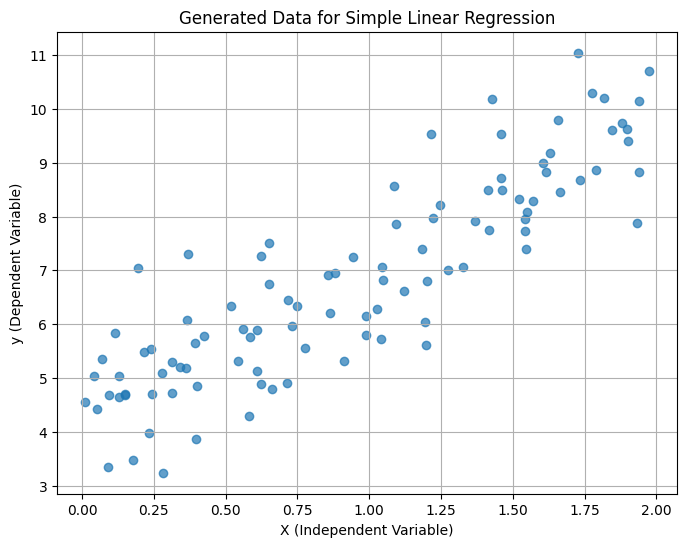

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate some sample data
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # Independent variable
y = 4 + 3 * X + np.random.randn(100, 1) # Dependent variable with some noise

plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.7)
plt.title('Generated Data for Simple Linear Regression')
plt.xlabel('X (Independent Variable)')
plt.ylabel('y (Dependent Variable)')
plt.grid(True)
plt.show()

In [ ]:
# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training data shape: X_train=(80, 1), y_train=(80, 1)
Testing data shape: X_test=(20, 1), y_test=(20, 1)


In [ ]:
# 3. Create and train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model Intercept (β₀): {model.intercept_[0]:.2f}")
print(f"Model Coefficient (β₁): {model.coef_[0][0]:.2f}")

Model Intercept (β₀): 4.14
Model Coefficient (β₁): 2.80


In [ ]:
# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 0.65
R-squared (R²): 0.81


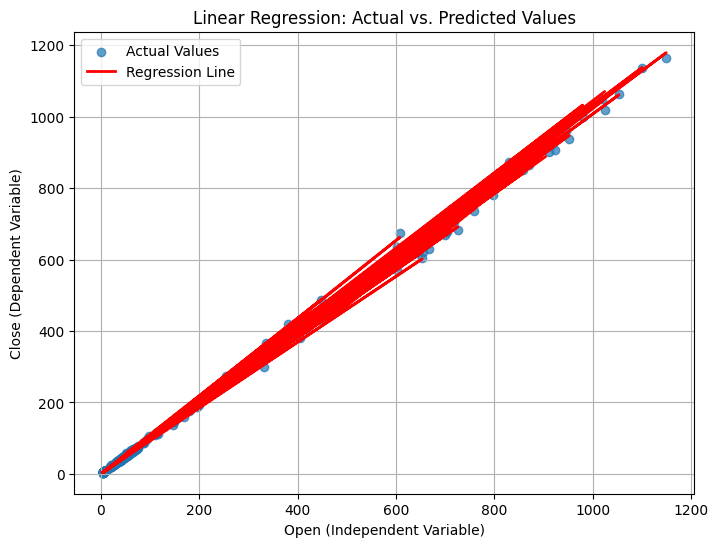

In [ ]:
import matplotlib.pyplot as plt
# 6. Visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(X_test['Open'], y_test, alpha=0.7, label='Actual Values')
plt.plot(X_test['Open'], l_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Open (Independent Variable)')
plt.ylabel('Close (Dependent Variable)')
plt.legend()
plt.grid(True)
plt.show()

This comprehensive breakdown covers the theoretical aspects, key concepts, assumptions, and a practical Python implementation of Simple Linear Regression. This should be very useful for understanding the topic and for interview preparation!

# Tesla Stock Predition

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor  # Corrected import
from sklearn.ensemble import RandomForestRegressor # Corrected import and typo
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Tesla')
print(df.head())

         Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500


In [ ]:
# need to difine x and y to represent the data so we use data

x = df[['Open', 'High', 'Low','Volume']]
y = df['Close'] # Target variable

In [ ]:
# Train and test (need to divide Train & Test)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training data shape: X_train=(2364, 4), y_train=(2364,)
Testing data shape: X_test=(592, 4), y_test=(592,)


In [ ]:
# Create and train a Linear Regression model

l_model = LinearRegression()
l_model.fit(X_train, y_train) # Train model
l_pred = l_model.predict(X_test) # Predict on test data

In [ ]:
# 5. Evaluate the model
mse = mean_squared_error(y_test, l_pred)
r2 = r2_score(y_test, l_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 20.60
R-squared (R²): 1.00


In [ ]:
# Linear Regression Accuracy

l_accuracy = r2_score(y_test, l_pred)
print(f"Linear Regression Accuracy Testing: {l_accuracy * 100:.2f}%")

print(f" Linear Regression Accuracy for Training: {l_model.score(X_train, y_train) * 100:.2f}%")



Linear Regression Accuracy Testing: 99.96%
 Linear Regression Accuracy for Training: 99.98%


## Decision Tree Model

In [ ]:
D_Model = DecisionTreeRegressor()
D_Model.fit(X_train, y_train)
D_pred = D_Model.predict(X_test)

mse2 = mean_squared_error(y_test, D_pred)
r2_d = r2_score(y_test, D_pred)
rms2 = np.sqrt(mse2)

print(f"Mean Squared Error (MSE): {mse2:.2f}")
print(f"Root Mean Squared Error (RMSE): {rms2:.2f}")
print(f"R-squared (R²) Decision tree acuuracy: {r2_d *100:.2f}")
#print(f" Decision Tree Regression Accuracy for Training: {D_Model.score(X_train, y_train) * 100:.2f}%")



Mean Squared Error (MSE): 33.47
Root Mean Squared Error (RMSE): 5.79
R-squared (R²) Decision tree acuuracy: 99.94


## Random Forest

In [ ]:
R_model = RandomForestRegressor()
R_model.fit(X_train, y_train)
R_pred = R_model.predict(X_test)

mse3 = mean_squared_error(y_test, R_pred)
rmse3 = np.sqrt(mse3)
r2_rf = r2_score(y_test, R_pred)

print(f"Mean Squared Error (MSE): {mse3:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse3:.2f}")
print(f"R-squared (R²) Random Forest Accuracy: {r2_rf *100:.2f}")

Mean Squared Error (MSE): 27.93
Root Mean Squared Error (RMSE): 5.28
R-squared (R²) Random Forest Accuracy: 99.95
